## My Question
### ***Write your question here***. What is the average height of a Pokemon and is there a Pokemon that is super tall?

### Study Description
my study is a census because it is taking the height of every single pokemon in the data table.

### Analysis


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("pokemon.csv")
df.head()

,national_number,gen,english_name,japanese_name,primary_type,secondary_type,classification,percent_male,percent_female,height_m,...,evochain_1,evochain_2,evochain_3,evochain_4,evochain_5,evochain_6,gigantamax,mega_evolution,mega_evolution_alt,description
0,1,I,Bulbasaur,Fushigidane,grass,poison,Seed Pokémon,87.5,12.5,0.7,...,Level,Ivysaur,Level,Venusaur,NaN,NaN,NaN,NaN,NaN,There is a plant seed on its back right from t...
1,2,I,Ivysaur,Fushigisou,grass,poison,Seed Pokémon,87.5,12.5,1.0,...,Level,Ivysaur,Level,Venusaur,NaN,NaN,NaN,NaN,NaN,"When the bulb on its back grows large, it appe..."
2,3,I,Venusaur,Fushigibana,grass,poison,Seed Pokémon,87.5,12.5,2.0,...,Level,Ivysaur,Level,Venusaur,NaN,NaN,Gigantamax Venusaur,Mega Venusaur,NaN,Its plant blooms when it is absorbing solar en...
3,4,I,Charmander,Hitokage,fire,NaN,Lizard Pokémon,87.5,12.5,0.6,...,Level,Charmeleon,Level,Charizard,NaN,NaN,NaN,NaN,NaN,It has a preference for hot things. When it ra...
4,5,I,Charmeleon,Lizardo,fire,NaN,Flame Pokémon,87.5,12.5,1.1,...,Level,Charmeleon,Level,Charizard,NaN,NaN,NaN,NaN,NaN,"It has a barbaric nature. In battle, it whips ..."


In [7]:
avg_height = df['height_m'].mean
tallest_pokemon = df.loc[df['height_m'].idxmax()]

bins = [0, 0.5, 1.0, 2.0, 5.0, 10.0, 25.0]
labels = ['Tiny (<0.5m)', 'Small (0.5m-1m)', 'Medium (1m-2m)', 
          'Large (2m-5m)', 'Huge (5m-10m)', 'Super Tall (>10m)']


df['height_bin'] = pd.cut(df['height_m'], bins=bins, labels=labels)


binned_counts = df['height_bin'].value_counts().sort_index()
print(binned_counts)

height_bin
Tiny (<0.5m)         261
Small (0.5m-1m)      294
Medium (1m-2m)       369
Large (2m-5m)         86
Huge (5m-10m)         12
Super Tall (>10m)      3
Name: count, dtype: int64


In [14]:
q1 = df['height_m'].quantile(0.25)
q3 = df['height_m'].quantile(0.75)
iqr = q3 - q1
median_val = df['height_m'].median()

upper_bound = q3 + (1.5 * iqr)

print(f"Median Height: {median_val} m")
print(f"IQR: {iqr:.2f} m")
print(f"Outlier Threshold: {upper_bound:.2f} m")
print(q3)

Median Height: 1.0 m
IQR: 1.00 m
Outlier Threshold: 3.00 m
1.5


In [9]:
outliers = df[df['height_m'] > upper_bound][['english_name', 'height_m']].sort_values(by='height_m', ascending=False)

print("\n--- Outlier Pokémon ---")
print(outliers.to_string(index=False))


--- Outlier Pokémon ---
english_name  height_m
   Eternatus      20.0
     Wailord      14.5
     Dondozo      12.0
     Steelix       9.2
  Celesteela       9.2
        Onix       8.8
    Rayquaza       7.0
    Gyarados       6.5
     Milotic       6.2
     Yveltal       5.8
   Stakataka       5.5
    Guzzlord       5.5
      Dialga       5.4
 Raging Bolt       5.2
       Lugia       5.2
     Zygarde       5.0
    Giratina       4.5
      Kyogre       4.5
     Cetitan       4.5
      Palkia       4.2
   Dragonair       4.0
      Lunala       4.0
    Dhelmise       3.9
       Ho-Oh       3.8
  Sandaconda       3.8
   Xurkitree       3.8
   Regigigas       3.7
 Dudunsparce       3.6
   Naganadel       3.6
       Arbok       3.5
     Groudon       3.5
    Miraidon       3.5
Walking Wake       3.5
Gouging Fire       3.5
    Solgaleo       3.4
   Serperior       3.3
      Arceus       3.2
    Reshiram       3.2
Slither Wing       3.2
   Farigiraf       3.2


### My Conclusion
1. The average jeight of a pokemon is 1m and yes there are some pokemon that are way larger than most and I know this using the IQR method, any Pokémon taller than $Q_3 + 1.5(\text{IQR})$ (approx. 3m) is an outlier.
2. The pokemon that are the greatest outliers are Eternatus (20m), Wailord (14.5m), Steelix (9.2m), and Onix (8.8m).

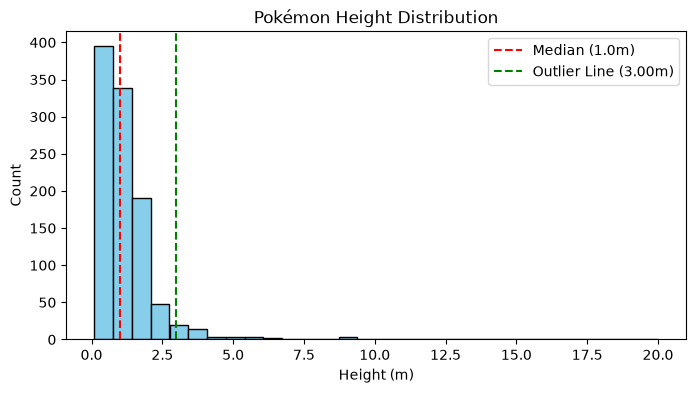

In [15]:
plt.figure(figsize=(8, 4))
plt.hist(df['height_m'].dropna(), bins=30, color='skyblue', edgecolor='black')

plt.axvline(median_val, color='red', linestyle='--', label=f'Median ({median_val}m)')
plt.axvline(upper_bound, color='green', linestyle='--', label=f'Outlier Line ({upper_bound:.2f}m)')

plt.xlabel('Height (m)')
plt.ylabel('Count')
plt.title('Pokémon Height Distribution')
plt.legend()
plt.show()

## https://www.desmos.com/calculator

## 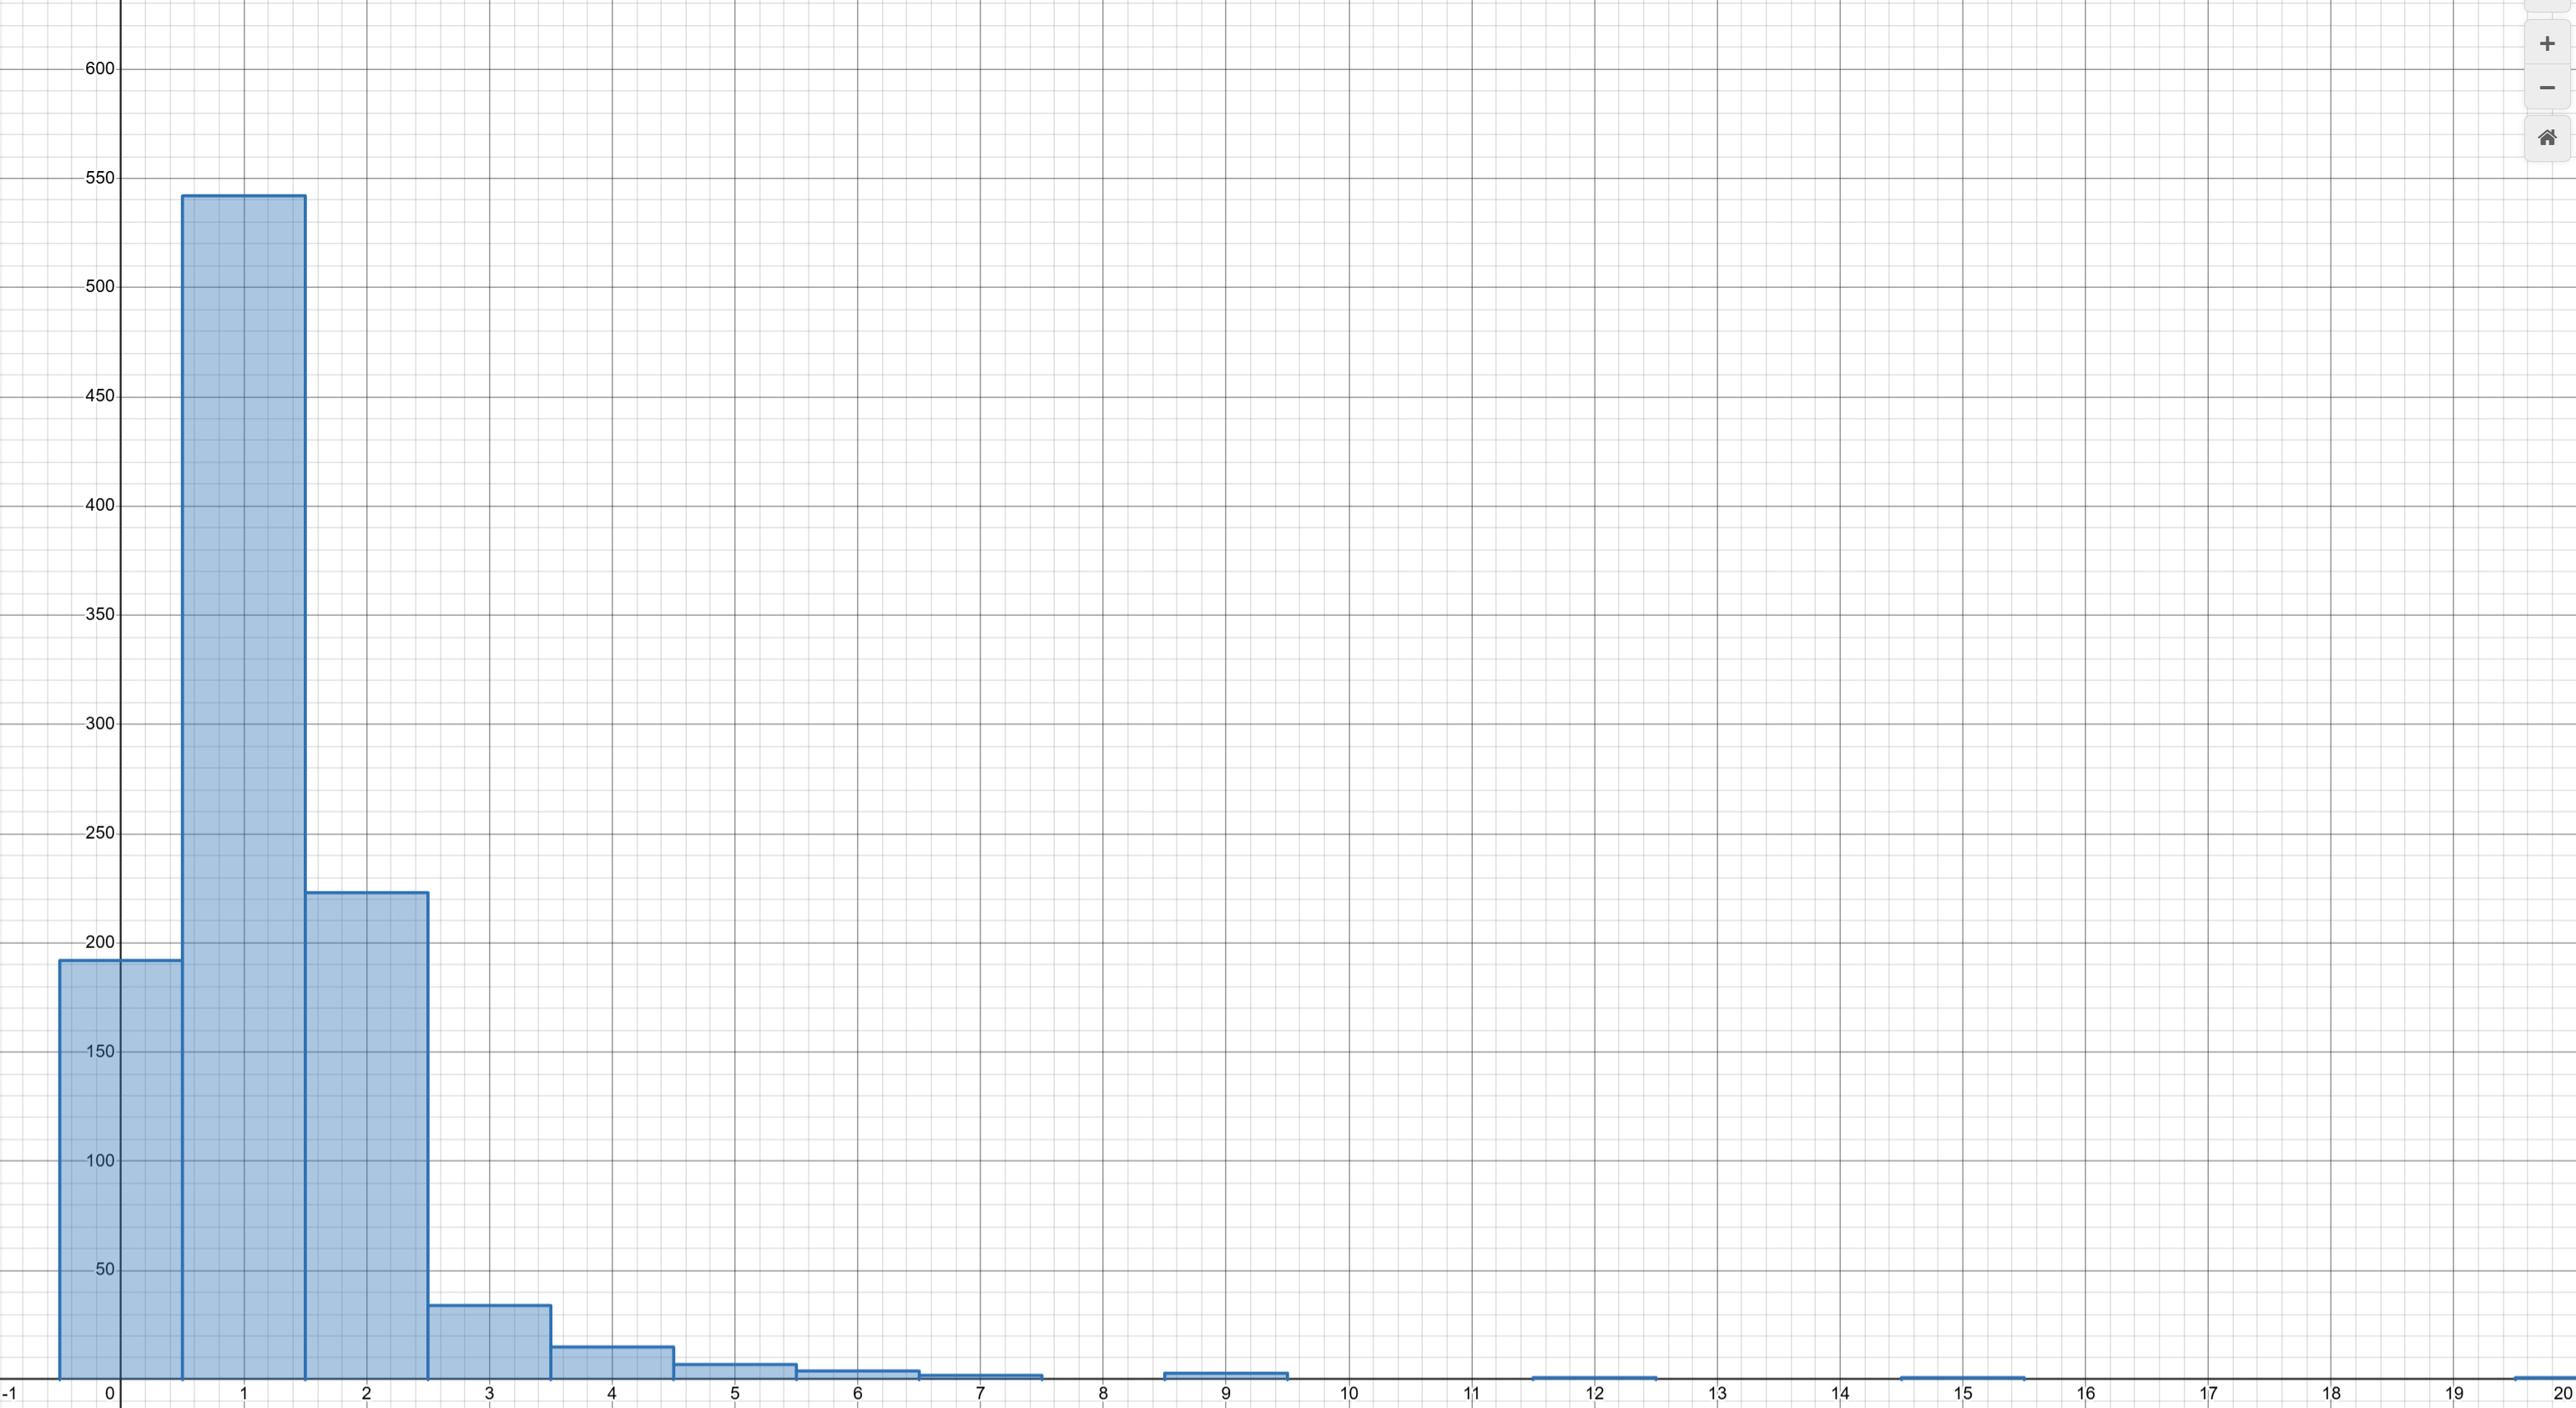

## 3. Interpret your graph. How does this graph support your answer?
My graph is a major skew right due to the outliers that sit at a very high height. The red line is the medain of the graph, and the green line is the outlier line which is created using the IQR. Everything to the right of the green line is an outlier.